In [1]:
# import packages
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

pd.options.mode.chained_assignment = None





In [2]:
# read the data
df = pd.read_csv('train.csv')

In [5]:
print(df.shape)
print(df.dtypes)


(30471, 292)
id                      int64
timestamp              object
full_sq                 int64
life_sq               float64
floor                 float64
                       ...   
mosque_count_5000       int64
leisure_count_5000      int64
sport_count_5000        int64
market_count_5000       int64
price_doc               int64
Length: 292, dtype: object


In [9]:
df_numeric = df.select_dtypes(include=[np.number])
numeric_cols = df_numeric.columns.values
df_non_numeric = df.select_dtypes(exclude=[np.number])
non_numeric_cols = df_non_numeric.columns.values
print(non_numeric_cols)

['timestamp' 'product_type' 'sub_area' 'culture_objects_top_25'
 'thermal_power_plant_raion' 'incineration_raion' 'oil_chemistry_raion'
 'radiation_raion' 'railroad_terminal_raion' 'big_market_raion'
 'nuclear_reactor_raion' 'detention_facility_raion' 'water_1line'
 'big_road1_1line' 'railroad_1line' 'ecology']


In [8]:
cols = df.columns[0:30] # first 30 columns
colours = ['#000099', '#ffff00'] # specify the colours - yellow is missing. blue is not missing.
sns.heatmap(df[cols].isnull(), cmap=sns.color_palette(colours))

NameError: name 'df' is not defined

In [19]:

# if it's a larger dataset and the visualization takes too long can do this.
# % of missing.
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

id - 0%
timestamp - 0%
full_sq - 0%
life_sq - 21%
floor - 1%
max_floor - 31%
material - 31%
build_year - 45%
num_room - 31%
kitch_sq - 31%
state - 44%
product_type - 0%
sub_area - 0%
area_m - 0%
raion_popul - 0%
green_zone_part - 0%
indust_part - 0%
children_preschool - 0%
preschool_quota - 22%
preschool_education_centers_raion - 0%
children_school - 0%
school_quota - 22%
school_education_centers_raion - 0%
school_education_centers_top_20_raion - 0%
hospital_beds_raion - 47%
healthcare_centers_raion - 0%
university_top_20_raion - 0%
sport_objects_raion - 0%
additional_education_raion - 0%
culture_objects_top_25 - 0%
culture_objects_top_25_raion - 0%
shopping_centers_raion - 0%
office_raion - 0%
thermal_power_plant_raion - 0%
incineration_raion - 0%
oil_chemistry_raion - 0%
radiation_raion - 0%
railroad_terminal_raion - 0%
big_market_raion - 0%
nuclear_reactor_raion - 0%
detention_facility_raion - 0%
full_all - 0%
male_f - 0%
female_f - 0%
young_all - 0%
young_male - 0%
young_female - 0

created missing indicator for: life_sq
created missing indicator for: floor
created missing indicator for: max_floor
created missing indicator for: material
created missing indicator for: build_year
created missing indicator for: num_room
created missing indicator for: kitch_sq
created missing indicator for: state
created missing indicator for: preschool_quota
created missing indicator for: school_quota
created missing indicator for: hospital_beds_raion
created missing indicator for: raion_build_count_with_material_info
created missing indicator for: build_count_block
created missing indicator for: build_count_wood
created missing indicator for: build_count_frame
created missing indicator for: build_count_brick
created missing indicator for: build_count_monolith
created missing indicator for: build_count_panel
created missing indicator for: build_count_foam
created missing indicator for: build_count_slag
created missing indicator for: build_count_mix
created missing indicator for: raio

<AxesSubplot:xlabel='index'>

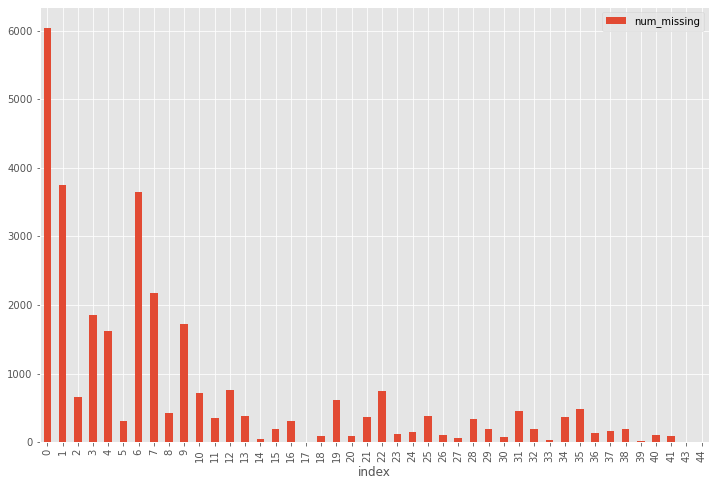

In [20]:
# first create missing indicator for features with missing data
for col in df.columns:
    missing = df[col].isnull()
    num_missing = np.sum(missing)
    
    if num_missing > 0:  
        print('created missing indicator for: {}'.format(col))
        df['{}_ismissing'.format(col)] = missing


# then based on the indicator, plot the histogram of missing values
ismissing_cols = [col for col in df.columns if 'ismissing' in col]
df['num_missing'] = df[ismissing_cols].sum(axis=1)

df['num_missing'].value_counts().reset_index().sort_values(by='index').plot.bar(x='index', y='num_missing')


In [3]:
df1 = pd.read_excel("HR Dataset.xlsx")

In [4]:
df1.head()

,Serial No,Age,Qualification,Experience,Domain,Skill,Designation,Project,Salary,Rating,ESS,Status
0,1,25,MCA,3,BFSI,Java,SE,Citi Bank,4.0,5,4.10,Left
1,2,26,MSc,4,BFSI,Oracle,SE,Citi Bank,4.0,4,3.15,Left
2,3,24,BE,2,BFSI,Java,SE,Bank of America,2.5,4,3.30,Left
3,4,31,MCA,9,Telecom,C++,Lead,Erickson,10.0,4,3.03,Left
4,5,30,Mtech,7,Telecom,Networking,Lead,Erickson,10.0,5,3.40,Left


In [9]:
df2 = pd.get_dummies(df1['Status'])

In [13]:
df1.drop('Status',axis = 1)


,Serial No,Age,Qualification,Experience,Domain,Skill,Designation,Project,Salary,Rating,ESS,Left,Not Left
0,1,25,MCA,3,BFSI,Java,SE,Citi Bank,4.0,5,4.10,1,0
1,2,26,MSc,4,BFSI,Oracle,SE,Citi Bank,4.0,4,3.15,1,0
2,3,24,BE,2,BFSI,Java,SE,Bank of America,2.5,4,3.30,1,0
3,4,31,MCA,9,Telecom,C++,Lead,Erickson,10.0,4,3.03,1,0
4,5,30,Mtech,7,Telecom,Networking,Lead,Erickson,10.0,5,3.40,1,0
5,6,27,BE,5,BFSI,Java,SSE,Bank of America,4.0,3,2.90,1,0
6,7,30,Graduate,8,BFSI,Mainframe,SSE,Wells Farago,6.0,3,3.00,1,0
7,8,31,Graduate,8,Telecom,C++,SSE,Erickson,6.0,3,3.10,1,0
8,9,27,Mtech,2,Telecom,Networking,SE,Erickson,4.0,5,3.20,1,0
9,10,24,MCA,2,BFSI,Java,SE,Citi Bank,3.0,4,3.30,1,0


In [11]:
df1 = df1.join(df2)

In [15]:
corr = df1.corr()

In [16]:
corr

,Serial No,Age,Experience,Salary,Rating,ESS,Left,Not Left
Serial No,1.000000,0.247025,0.226894,0.225267,-0.278286,0.037205,-0.866199,0.866199
Age,0.247025,1.000000,0.956044,0.869285,-0.509858,0.003936,-0.205777,0.205777
Experience,0.226894,0.956044,1.000000,0.857237,-0.551027,0.068844,-0.229986,0.229986
Salary,0.225267,0.869285,0.857237,1.000000,-0.298450,0.183772,-0.217435,0.217435
Rating,-0.278286,-0.509858,-0.551027,-0.298450,1.000000,0.314379,0.235460,-0.235460
ESS,0.037205,0.003936,0.068844,0.183772,0.314379,1.000000,-0.202567,0.202567
Left,-0.866199,-0.205777,-0.229986,-0.217435,0.235460,-0.202567,1.000000,-1.000000
Not Left,0.866199,0.205777,0.229986,0.217435,-0.235460,0.202567,-1.000000,1.000000
